In [1]:
#
# 설치
#

!pip install ultralytics roboflow

In [2]:
#
# google drive 연결
#

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#
# 데이터셋 다운로드
#

from google.colab import userdata
from roboflow import Roboflow

api_key = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=api_key)
project = rf.workspace("s-workspace-pv7pr").project("findeye_osp")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
#
# YOLO 학습
#

from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    project="/content/drive/MyDrive/FindEye",  # Google Drive에 저장
    name="weights"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FINDEYE_OSP-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c1d66246c60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

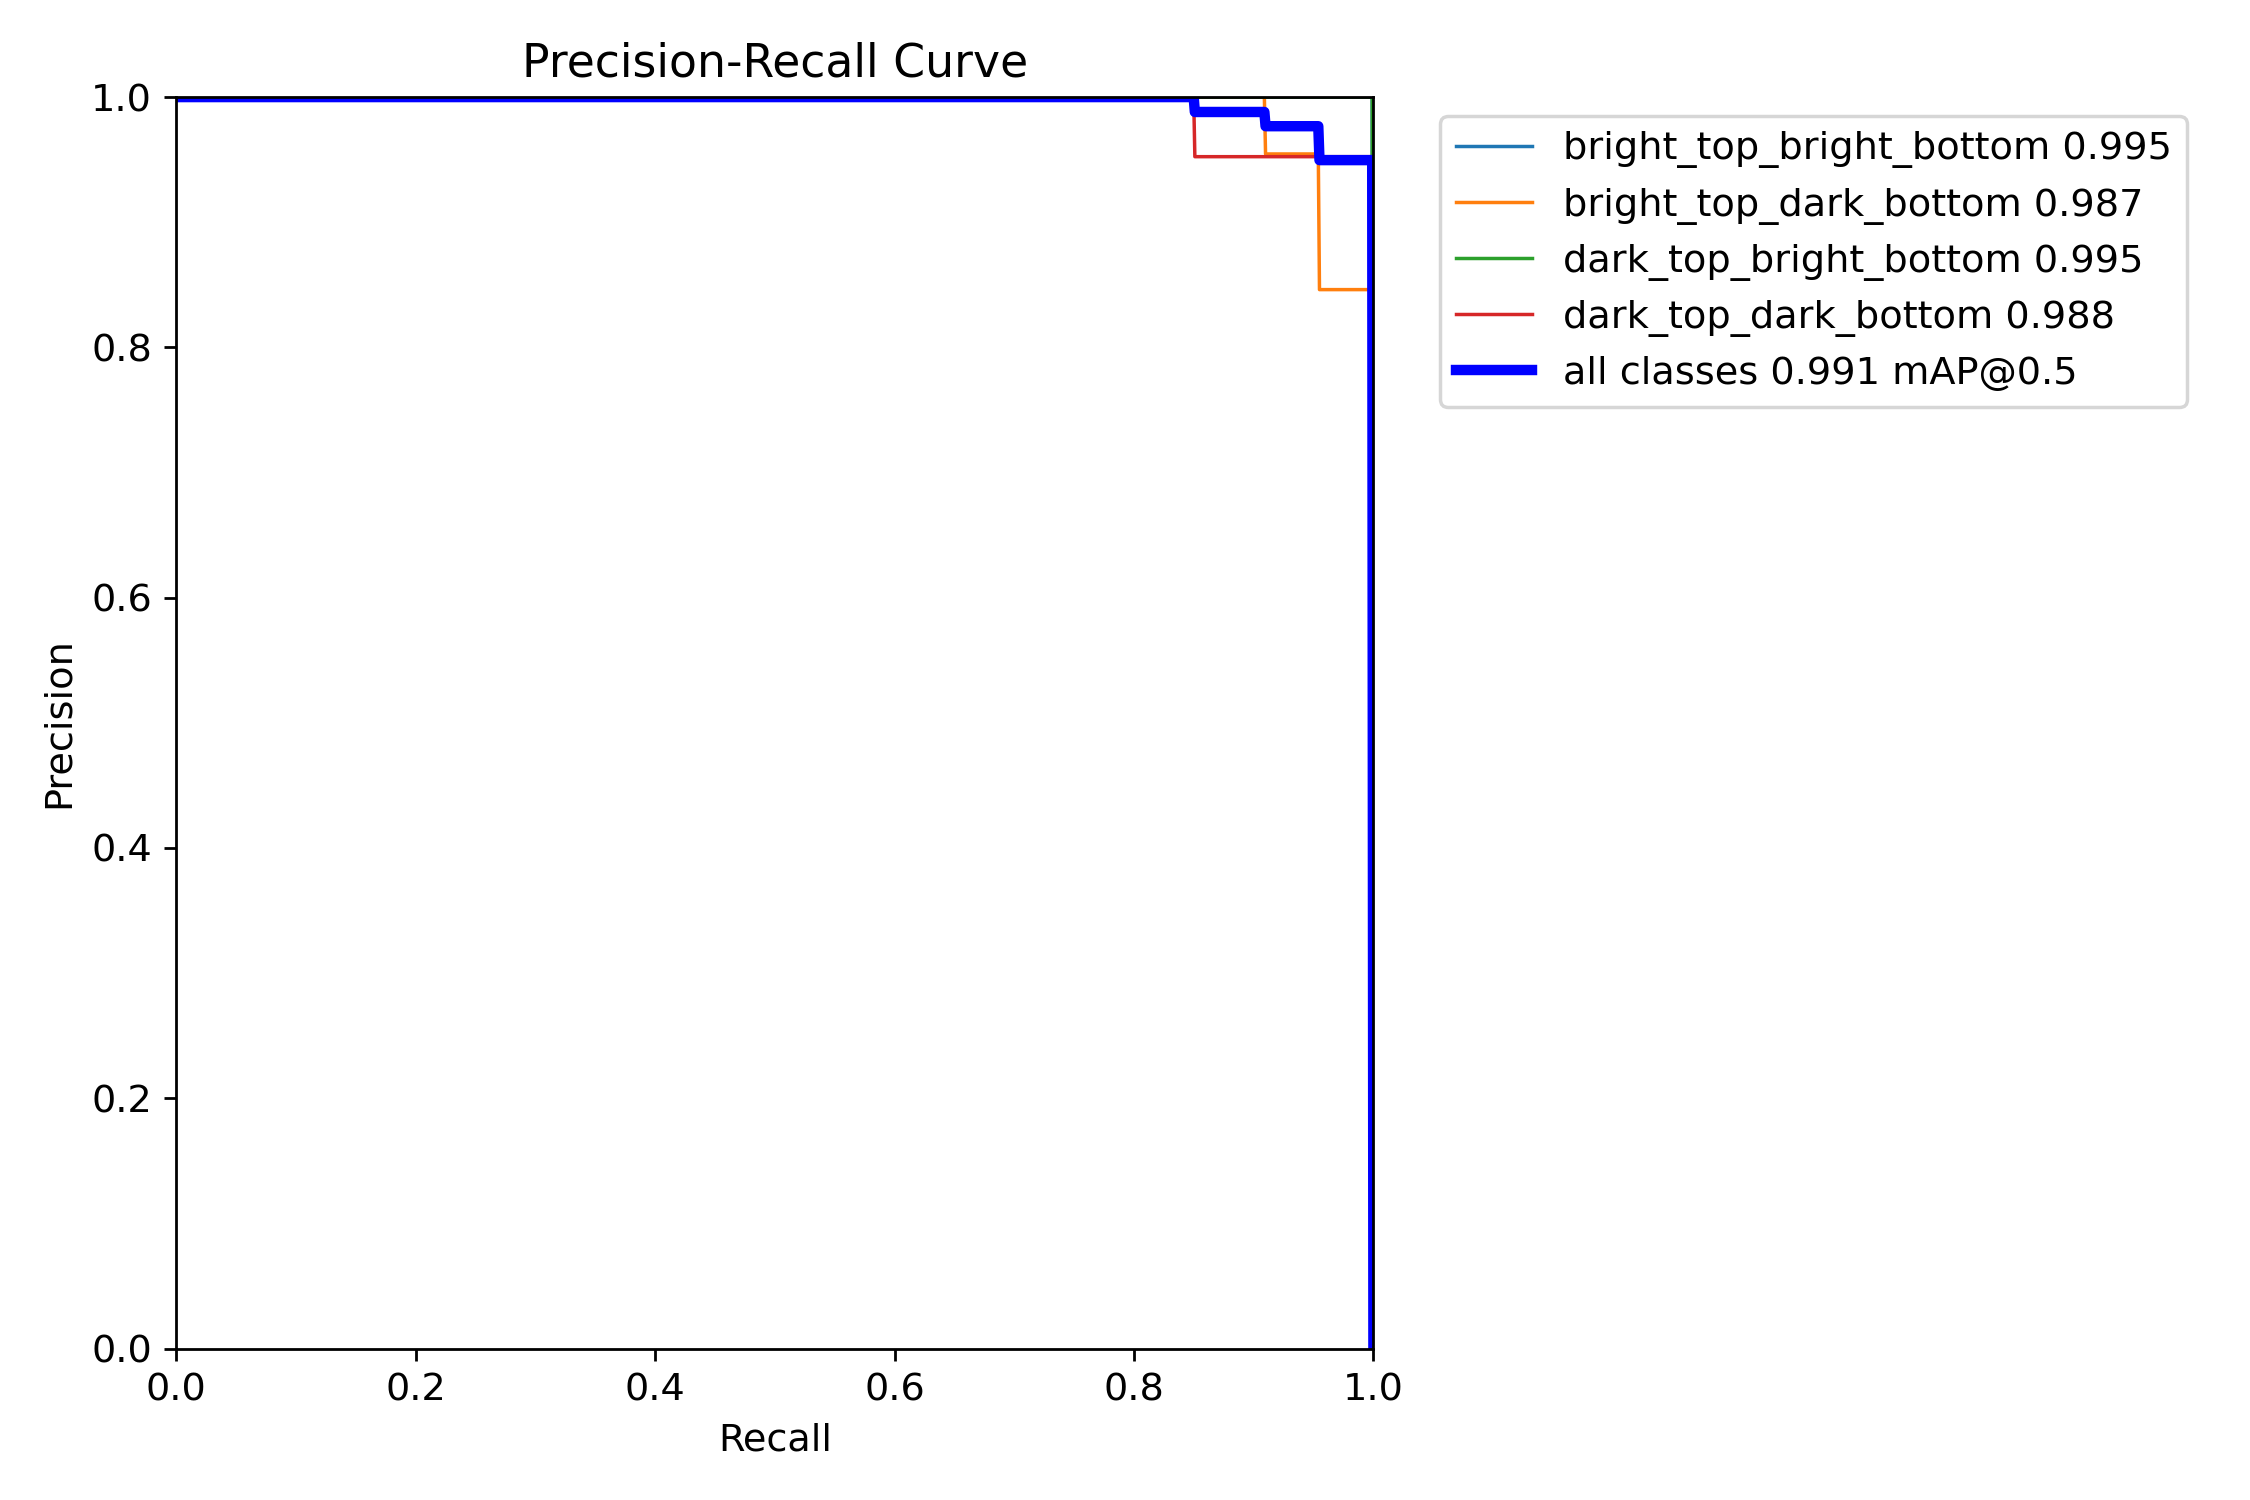

In [ ]:
#
# 학습결과확인
#

import glob
results = glob.glob("/content/drive/MyDrive/FindEye/weights/*.png")
from IPython.display import Image
Image(results[0])

**학습률(Learning Rate) 실험**

In [ ]:
from ultralytics import YOLO

# 기본 모델을 불러와서 학습률을 0.005로 변경하여 학습
model_lr = YOLO('yolo11s.pt')
results_lr = model_lr.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    lr0=0.005,                  # ★ 조작 변인: 학습률 변경
    project='FindEye_Experiments',
    name='lr_0005_exp'
)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FINDEYE_OSP-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lr_0005_exp-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

=== 1. 학습률(0.005) 실험: 학습 곡선 ===


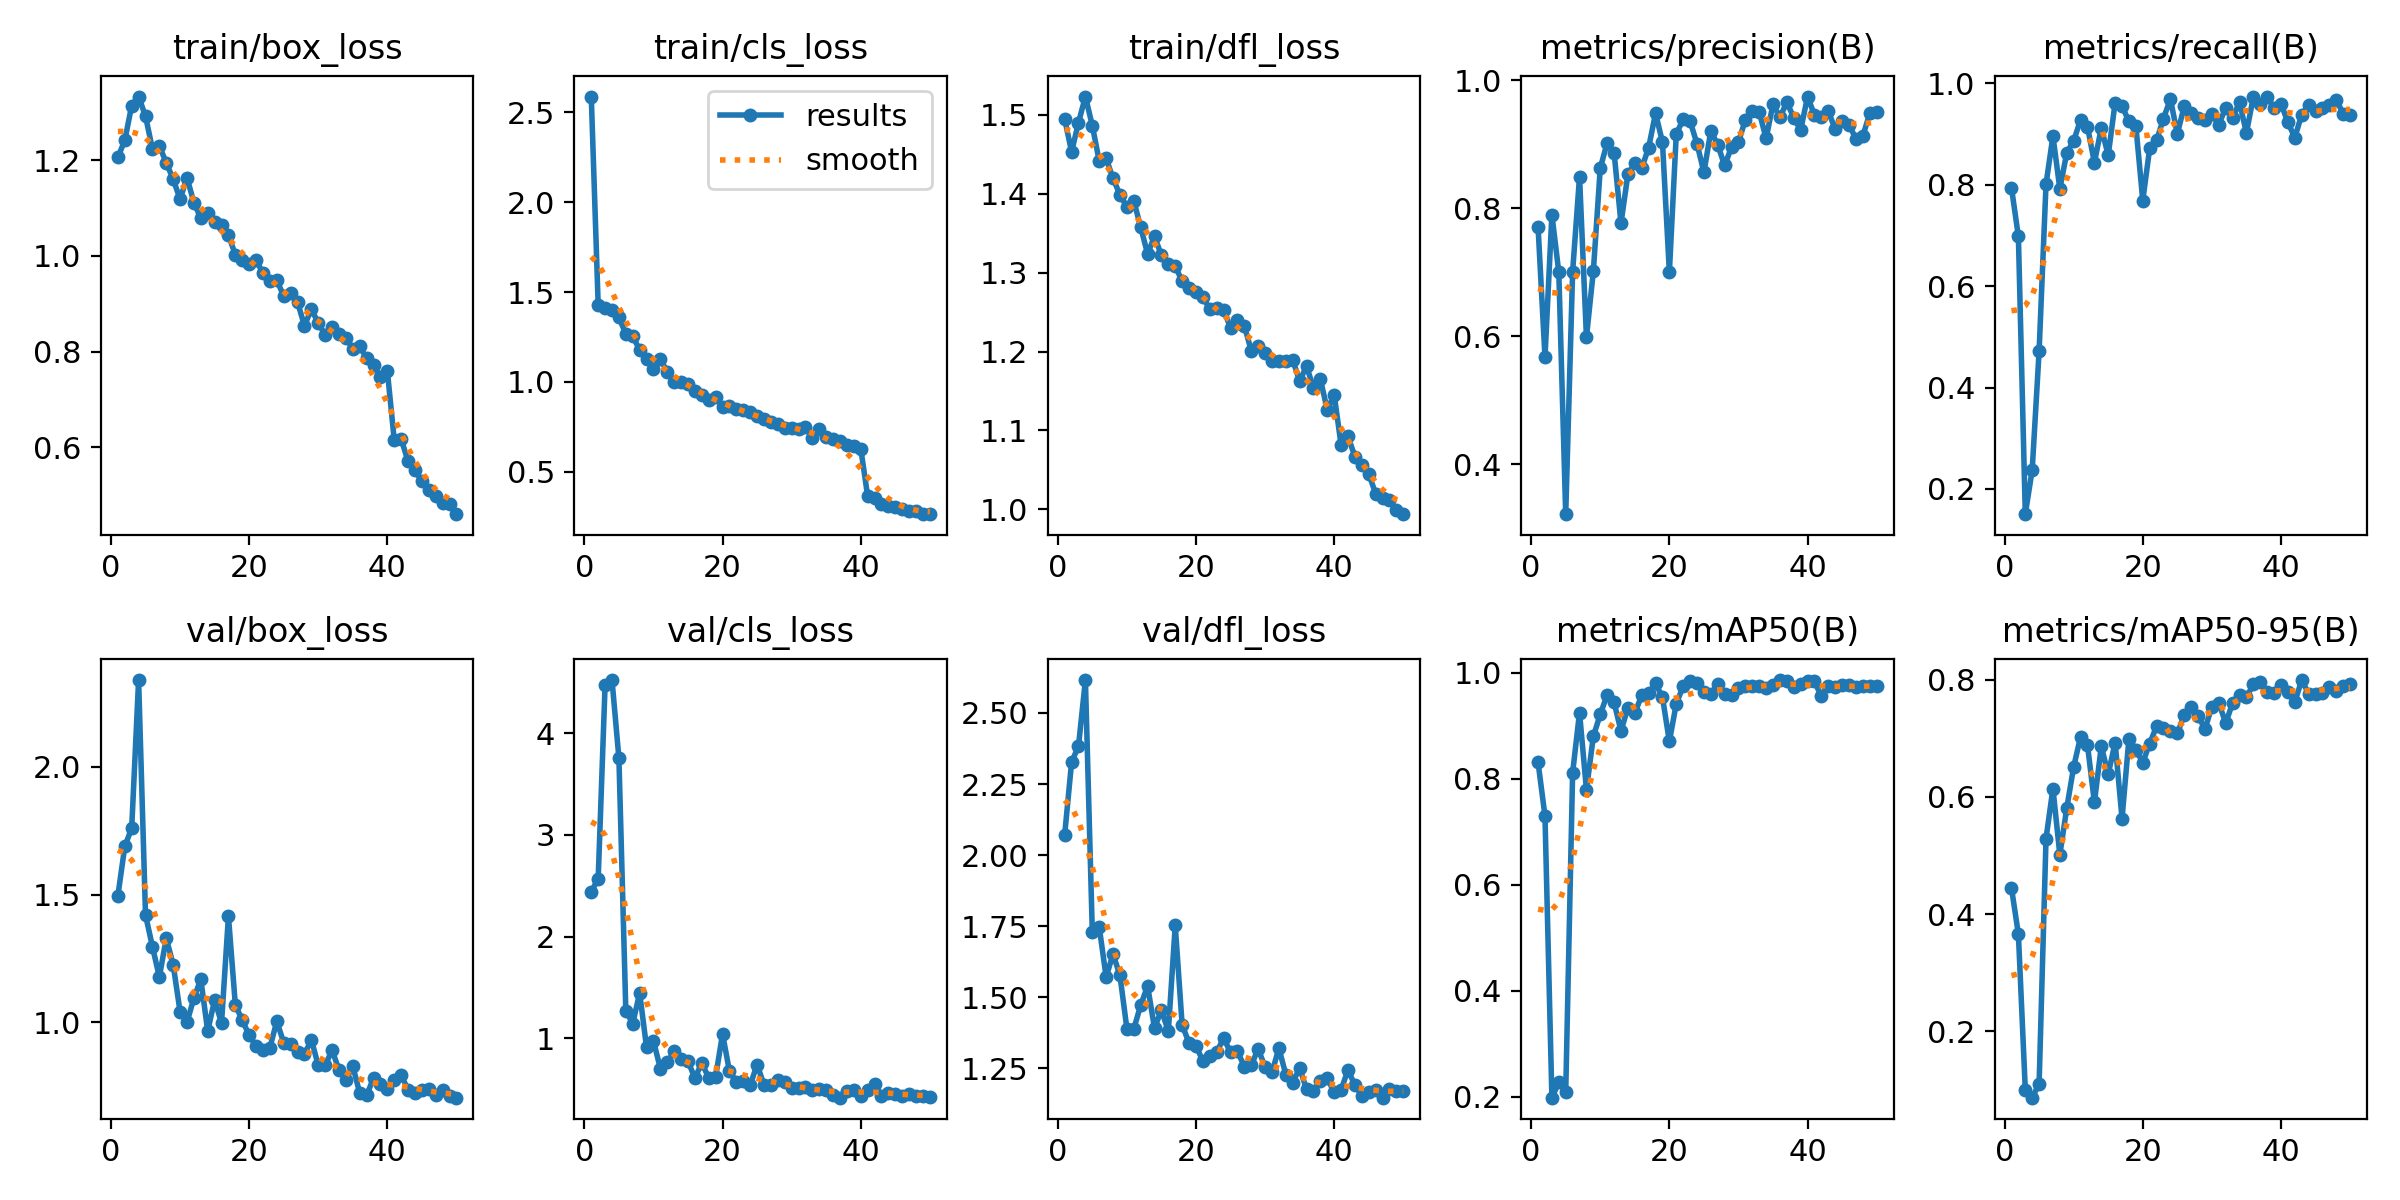


=== 1. 학습률(0.005) 실험: 오분류표 ===


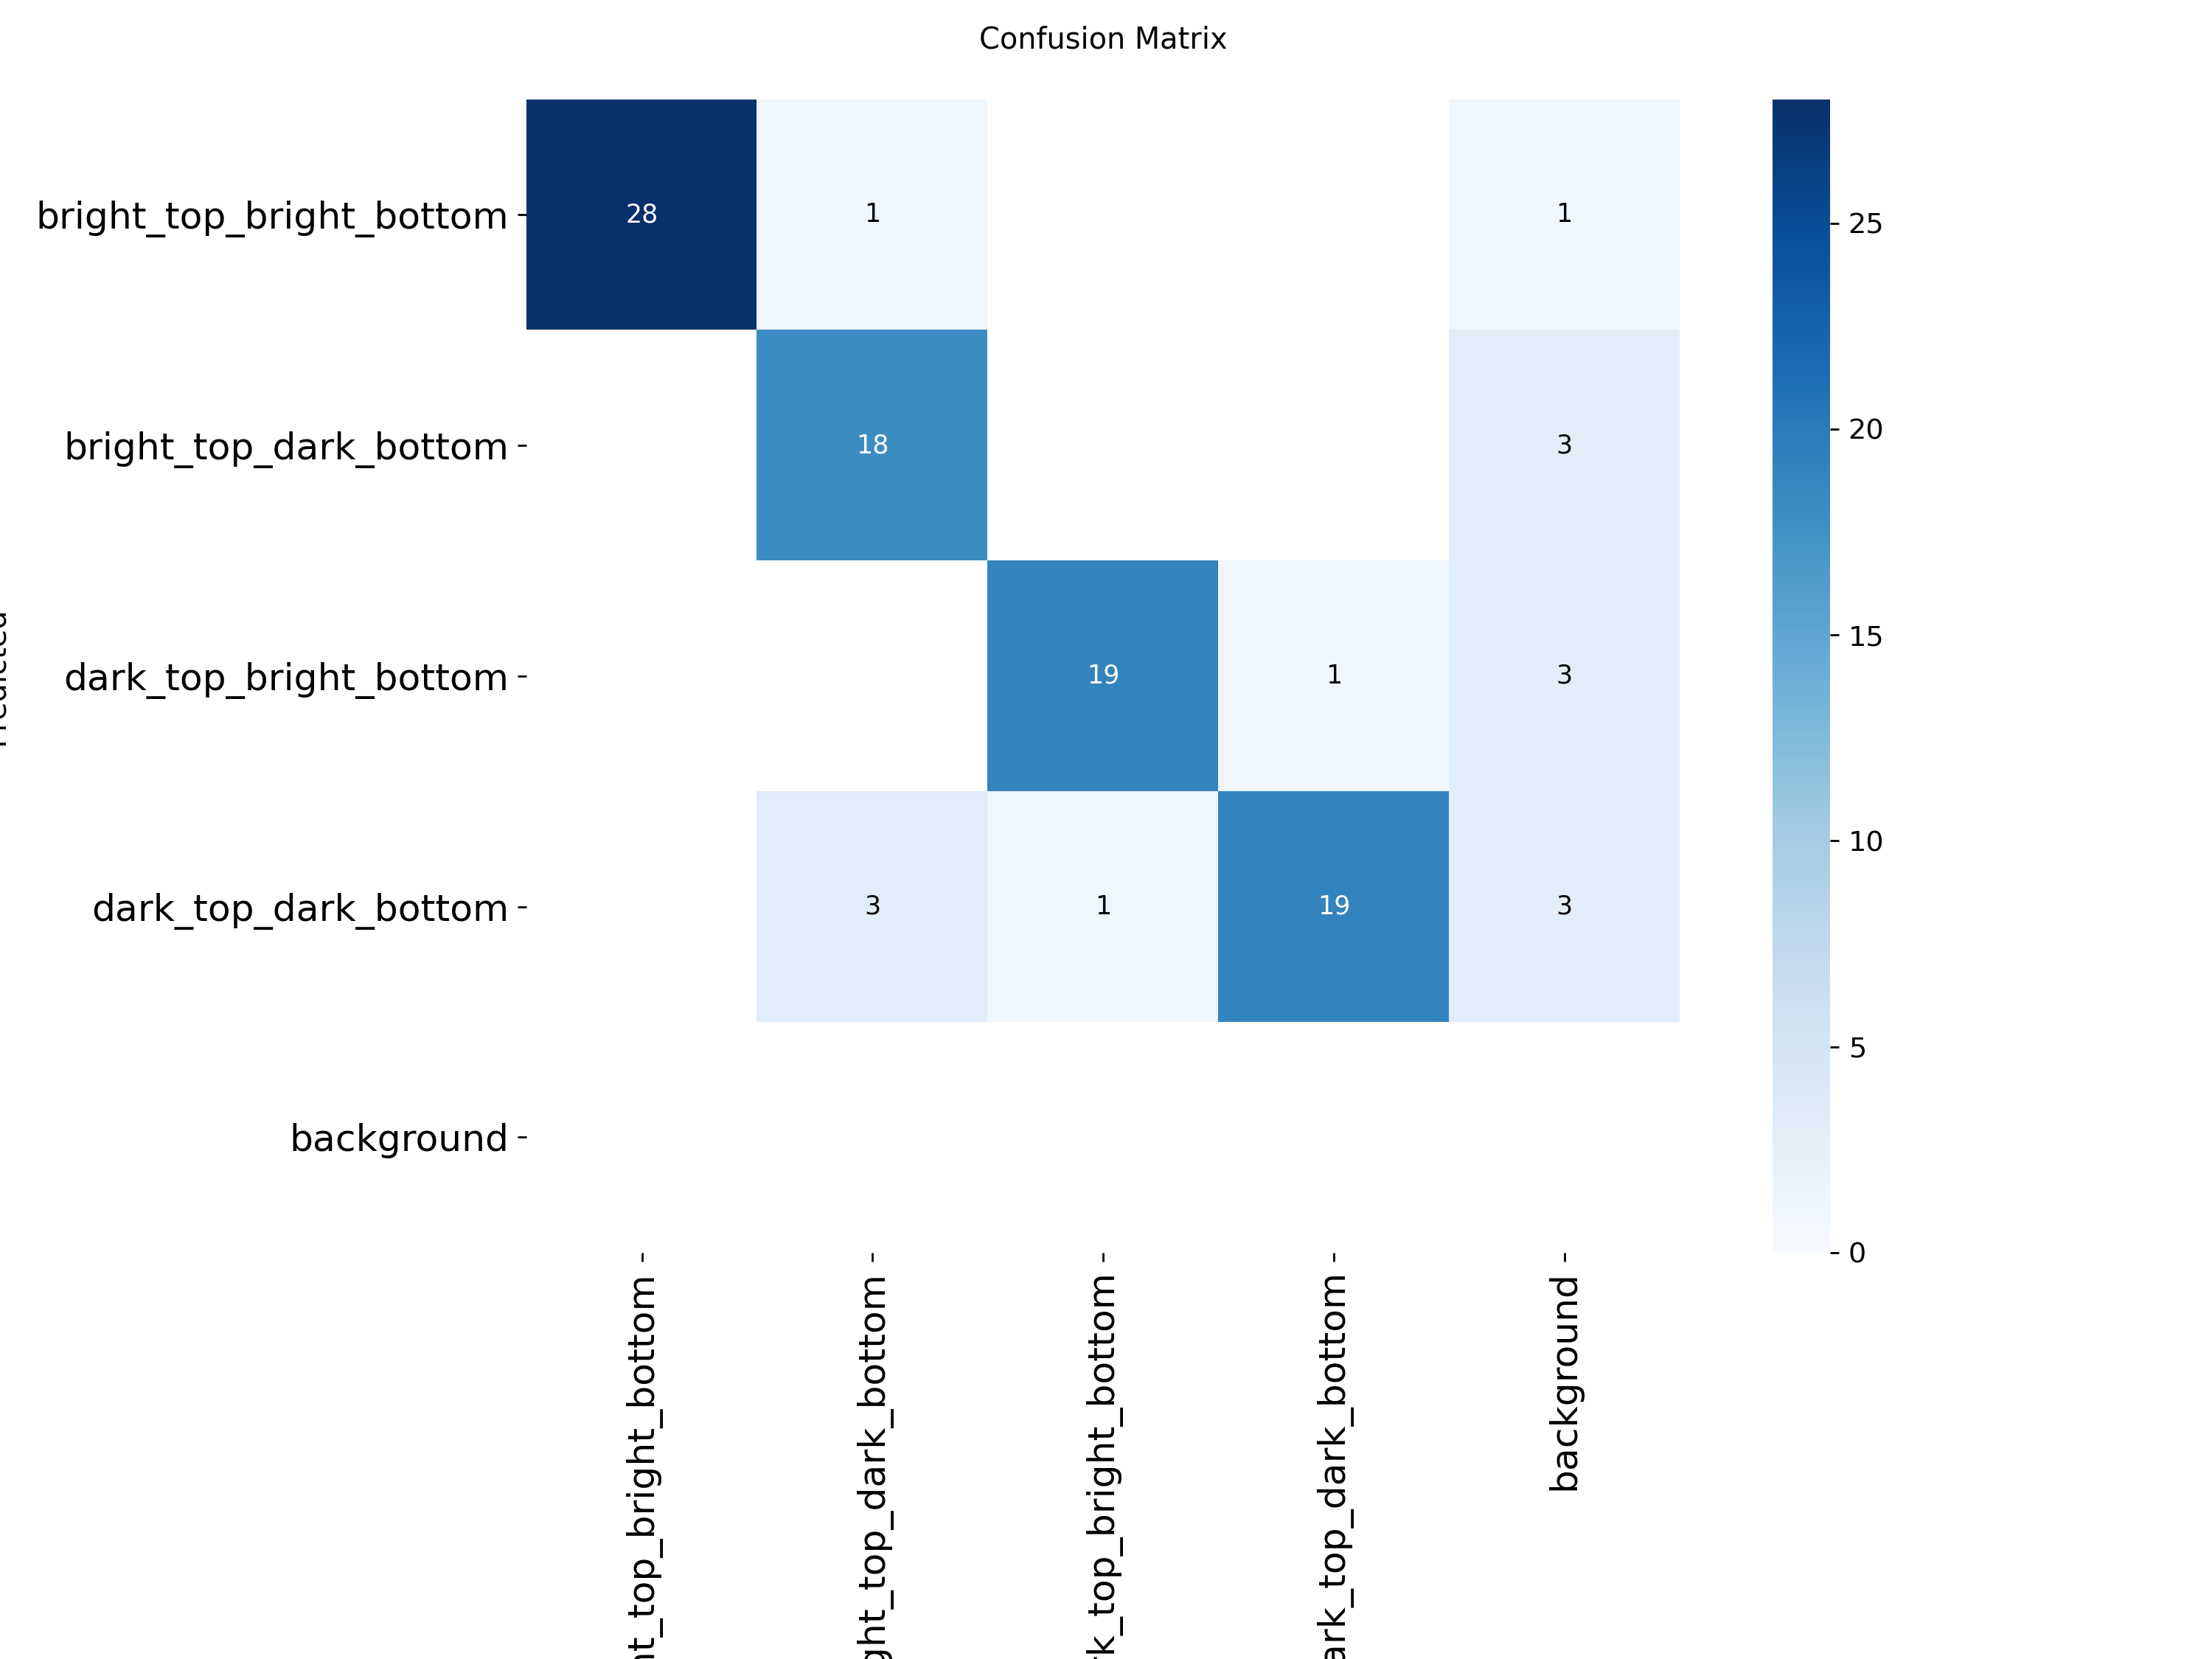

In [ ]:
from IPython.display import Image, display

print("=== 1. 학습률(0.005) 실험: 학습 곡선 ===")
display(Image('/content/runs/detect/FindEye_Experiments/lr_0005_exp-3/results.png'))

print("\n=== 1. 학습률(0.005) 실험: 오분류표 ===")
display(Image('/content/runs/detect/FindEye_Experiments/lr_0005_exp-3/confusion_matrix.png'))

**epoch=100으로 재실험**

In [15]:
from ultralytics import YOLO

# 아까 확인된 정확한 데이터셋 경로
yaml_path = "/content/FINDEYE_OSP-1/data.yaml"

print("=== [1] 원래 모델(Baseline) 100 Epoch 학습 ===")
model_base = YOLO('yolo11s.pt')
model_base.train(
    data=yaml_path,
    epochs=100,
    optimizer='SGD',   # 🚨 핵심: YOLO의 자동 덮어쓰기 방지
    lr0=0.01,          # 원래 모델 기본 학습률
    project='/content/runs/detect/FindEye_Final_Experiment',
    name='baseline_100e'
)

print("\n=== [2] 학습률 0.005 모델 100 Epoch 학습 ===")
model_opt = YOLO('yolo11s.pt')
model_opt.train(
    data=yaml_path,
    epochs=100,
    optimizer='SGD',   # 🚨 핵심: YOLO의 자동 덮어쓰기 방지
    lr0=0.005,         # 변경된 학습률
    project='/content/runs/detect/FindEye_Final_Experiment',
    name='optimized_100e'
)

=== [1] 원래 모델(Baseline) 100 Epoch 학습 ===
Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FINDEYE_OSP-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_100e-2, nbs=64, nms=False, opset=None, optimize=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a9d984cb8c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

🔍 찾은 Baseline 폴더: /content/runs/detect/FindEye_Final_Experiment/baseline_100e-2
🔍 찾은 Optimized 폴더: /content/runs/detect/FindEye_Final_Experiment/optimized_100e

=== 🏆 100 Epoch Final Metrics Comparison ===


,Model,Precision,Recall,mAP50,mAP50-95
0,Baseline (lr=0.01),0.9460,0.9359,0.9634,0.7889
1,Optimized (lr=0.005),0.9502,0.9822,0.9814,0.8194



=== 📈 Training Curves ===


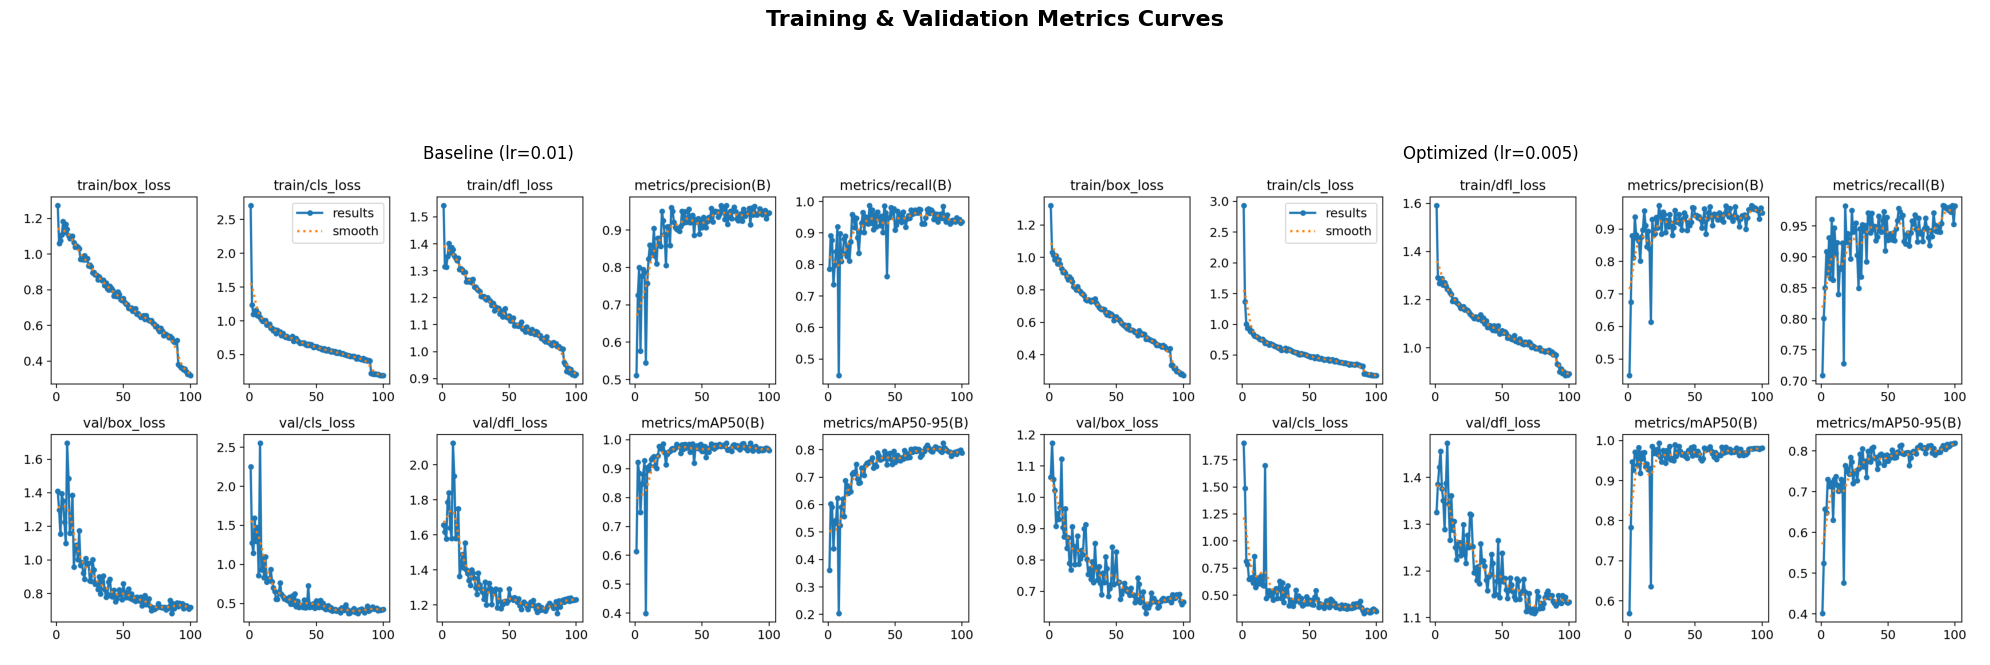


=== 🎯 Confusion Matrix ===


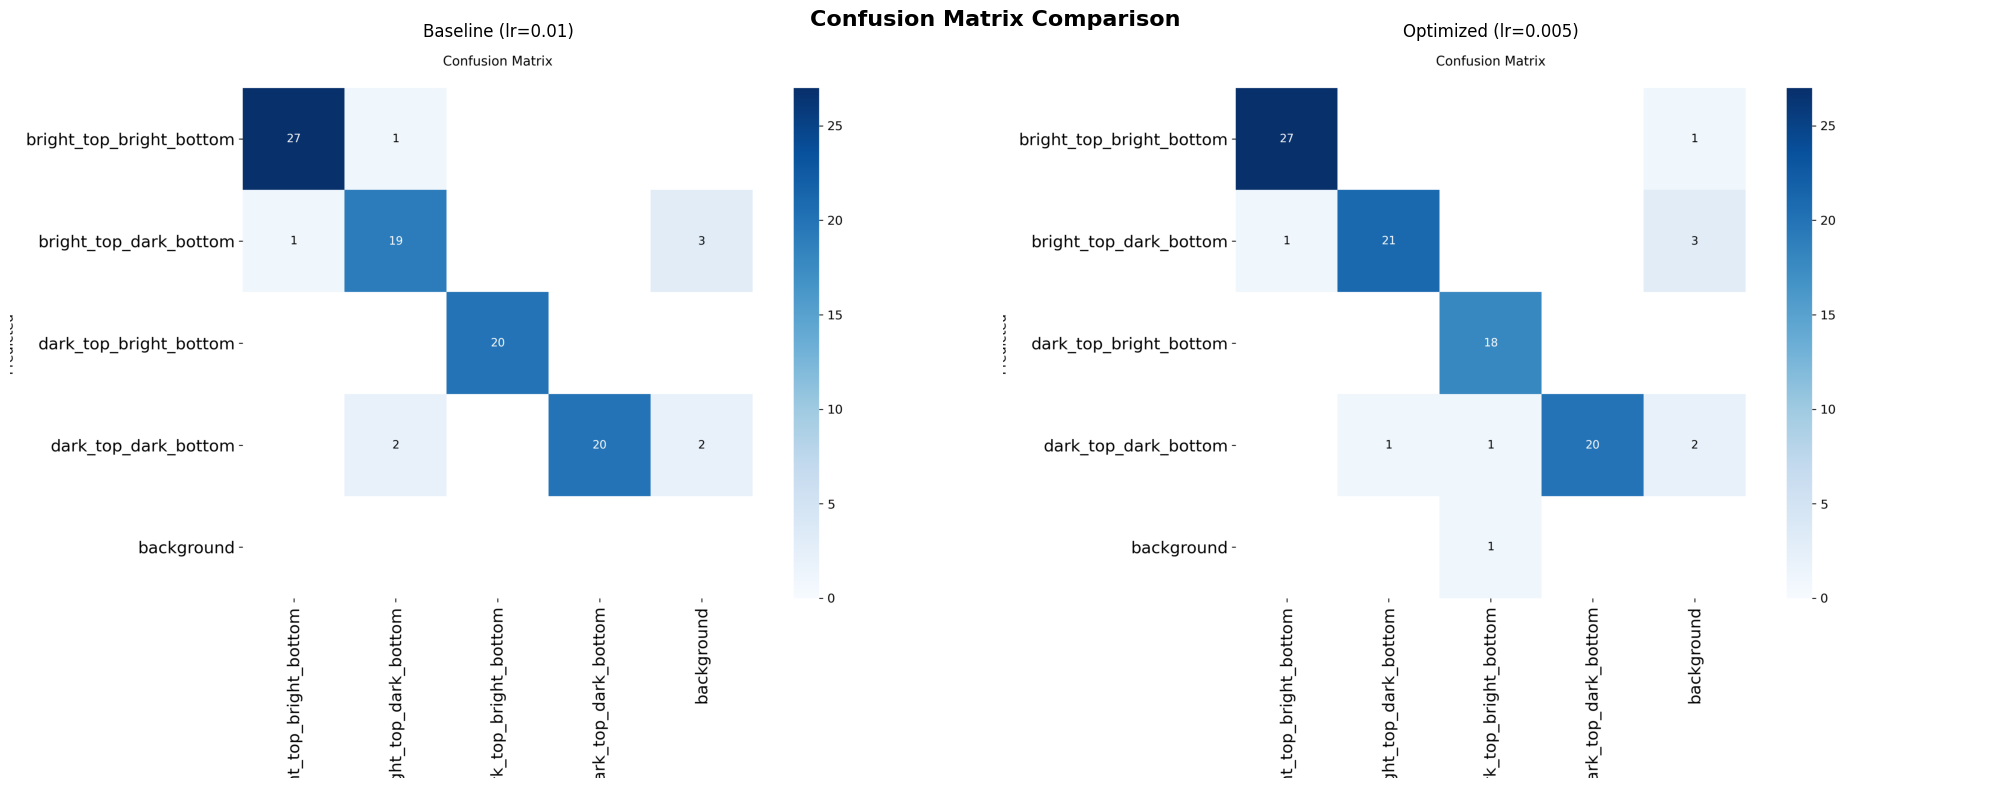

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import glob
from IPython.display import display

# ==========================================
# 🚨 이 부분 경로를 새 폴더로 수정했습니다! 🚨
# ==========================================
base_path = '/content/runs/detect/FindEye_Final_Experiment'

def find_valid_folder(prefix):
    folders = sorted(glob.glob(f'{base_path}/{prefix}*'))
    for folder in reversed(folders):
        if os.path.exists(f'{folder}/results.png'):
            return folder
    return None

baseline_dir = find_valid_folder('baseline_100e')
opt_dir = find_valid_folder('optimized_100e')

print(f"🔍 찾은 Baseline 폴더: {baseline_dir}")
print(f"🔍 찾은 Optimized 폴더: {opt_dir}")

def get_final_metrics(target_dir, model_name):
    if target_dir is None:
        return None

    csv_path = f'{target_dir}/results.csv'
    if not os.path.exists(csv_path):
        return None

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    last_epoch = df.iloc[-1]

    return {
        'Model': model_name,
        'Precision': round(last_epoch['metrics/precision(B)'], 4),
        'Recall': round(last_epoch['metrics/recall(B)'], 4),
        'mAP50': round(last_epoch['metrics/mAP50(B)'], 4),
        'mAP50-95': round(last_epoch['metrics/mAP50-95(B)'], 4)
    }

metrics_list = []
metrics_list.append(get_final_metrics(baseline_dir, 'Baseline (lr=0.01)'))
metrics_list.append(get_final_metrics(opt_dir, 'Optimized (lr=0.005)'))
metrics_list = [m for m in metrics_list if m is not None]

if metrics_list:
    print("\n=== 🏆 100 Epoch Final Metrics Comparison ===")
    display(pd.DataFrame(metrics_list))

def show_images_side_by_side(img_name, title):
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(title, fontsize=16, fontweight='bold')

    if baseline_dir and os.path.exists(f'{baseline_dir}/{img_name}'):
        axes[0].imshow(mpimg.imread(f'{baseline_dir}/{img_name}'))
        axes[0].set_title('Baseline (lr=0.01)')
        axes[0].axis('off')
    else:
        axes[0].set_title('No Baseline Image')

    if opt_dir and os.path.exists(f'{opt_dir}/{img_name}'):
        axes[1].imshow(mpimg.imread(f'{opt_dir}/{img_name}'))
        axes[1].set_title('Optimized (lr=0.005)')
        axes[1].axis('off')
    else:
        axes[1].set_title('No Optimized Image')

    plt.tight_layout()
    plt.show()

print("\n=== 📈 Training Curves ===")
show_images_side_by_side('results.png', 'Training & Validation Metrics Curves')

print("\n=== 🎯 Confusion Matrix ===")
show_images_side_by_side('confusion_matrix.png', 'Confusion Matrix Comparison')

In [13]:
import yaml

def check_lr(folder):
    yaml_path = f"{folder}/args.yaml"
    try:
        with open(yaml_path, 'r') as f:
            args = yaml.safe_load(f)
            print(f"🔍 [{folder.split('/')[-1]}] 폴더의 실제 학습률(lr0): {args.get('lr0')}")
    except Exception as e:
        print(f"❌ {folder} 에러 발생: {e}")

print("=== 🕵️‍♂️ 두 모델의 실제 학습률 설정 확인 ===")
check_lr('/content/runs/detect/FindEye_100e_Experiments/baseline_100e-4')
check_lr('/content/runs/detect/FindEye_100e_Experiments/optimized_100e')

=== 🕵️‍♂️ 두 모델의 실제 학습률 설정 확인 ===
🔍 [baseline_100e-4] 폴더의 실제 학습률(lr0): 0.01
🔍 [optimized_100e] 폴더의 실제 학습률(lr0): 0.005


**밝기 증강(Augmentation) 실험**

In [ ]:
from ultralytics import YOLO

model_aug = YOLO('yolo11s.pt')

# 두 번째 실험: 밝기 증강(Augmentation)
results_aug = model_aug.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    hsv_v=0.2,                  # ★ 조작 변인: 밝기 변형 파라미터 조절
    project='FindEye_Experiments',
    name='aug_brightness_exp'
)

Ultralytics 8.4.68 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/FINDEYE_OSP-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=aug_brightness_exp, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

=== 2. 밝기 증강 실험: 학습 곡선 (/content/runs/detect/FindEye_Experiments/aug_brightness_exp) ===


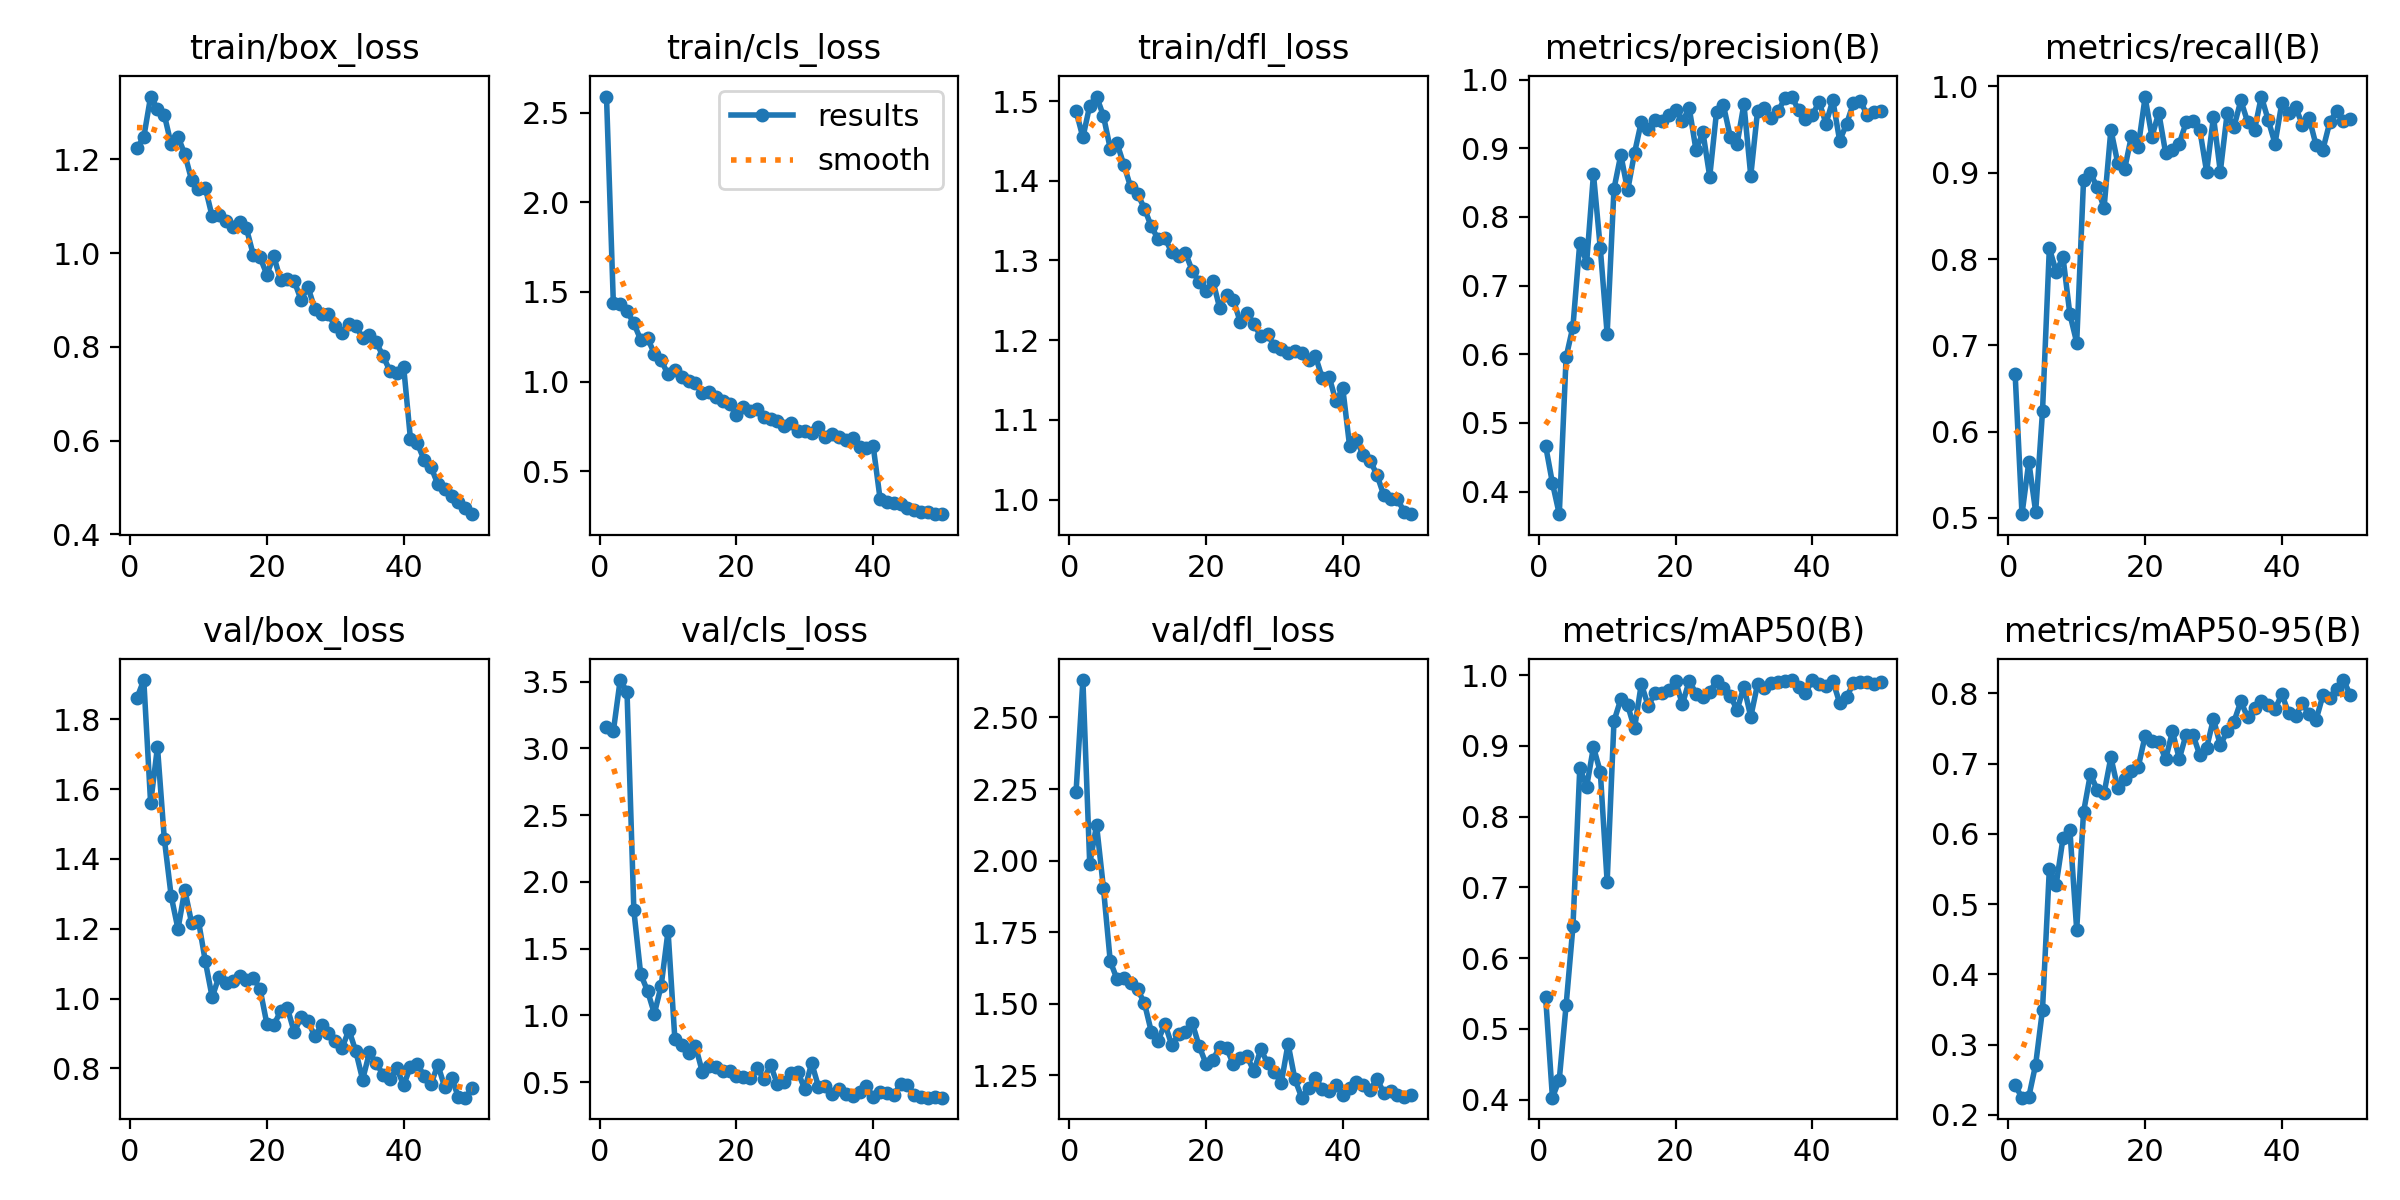


=== 2. 밝기 증강 실험: 오분류표 ===


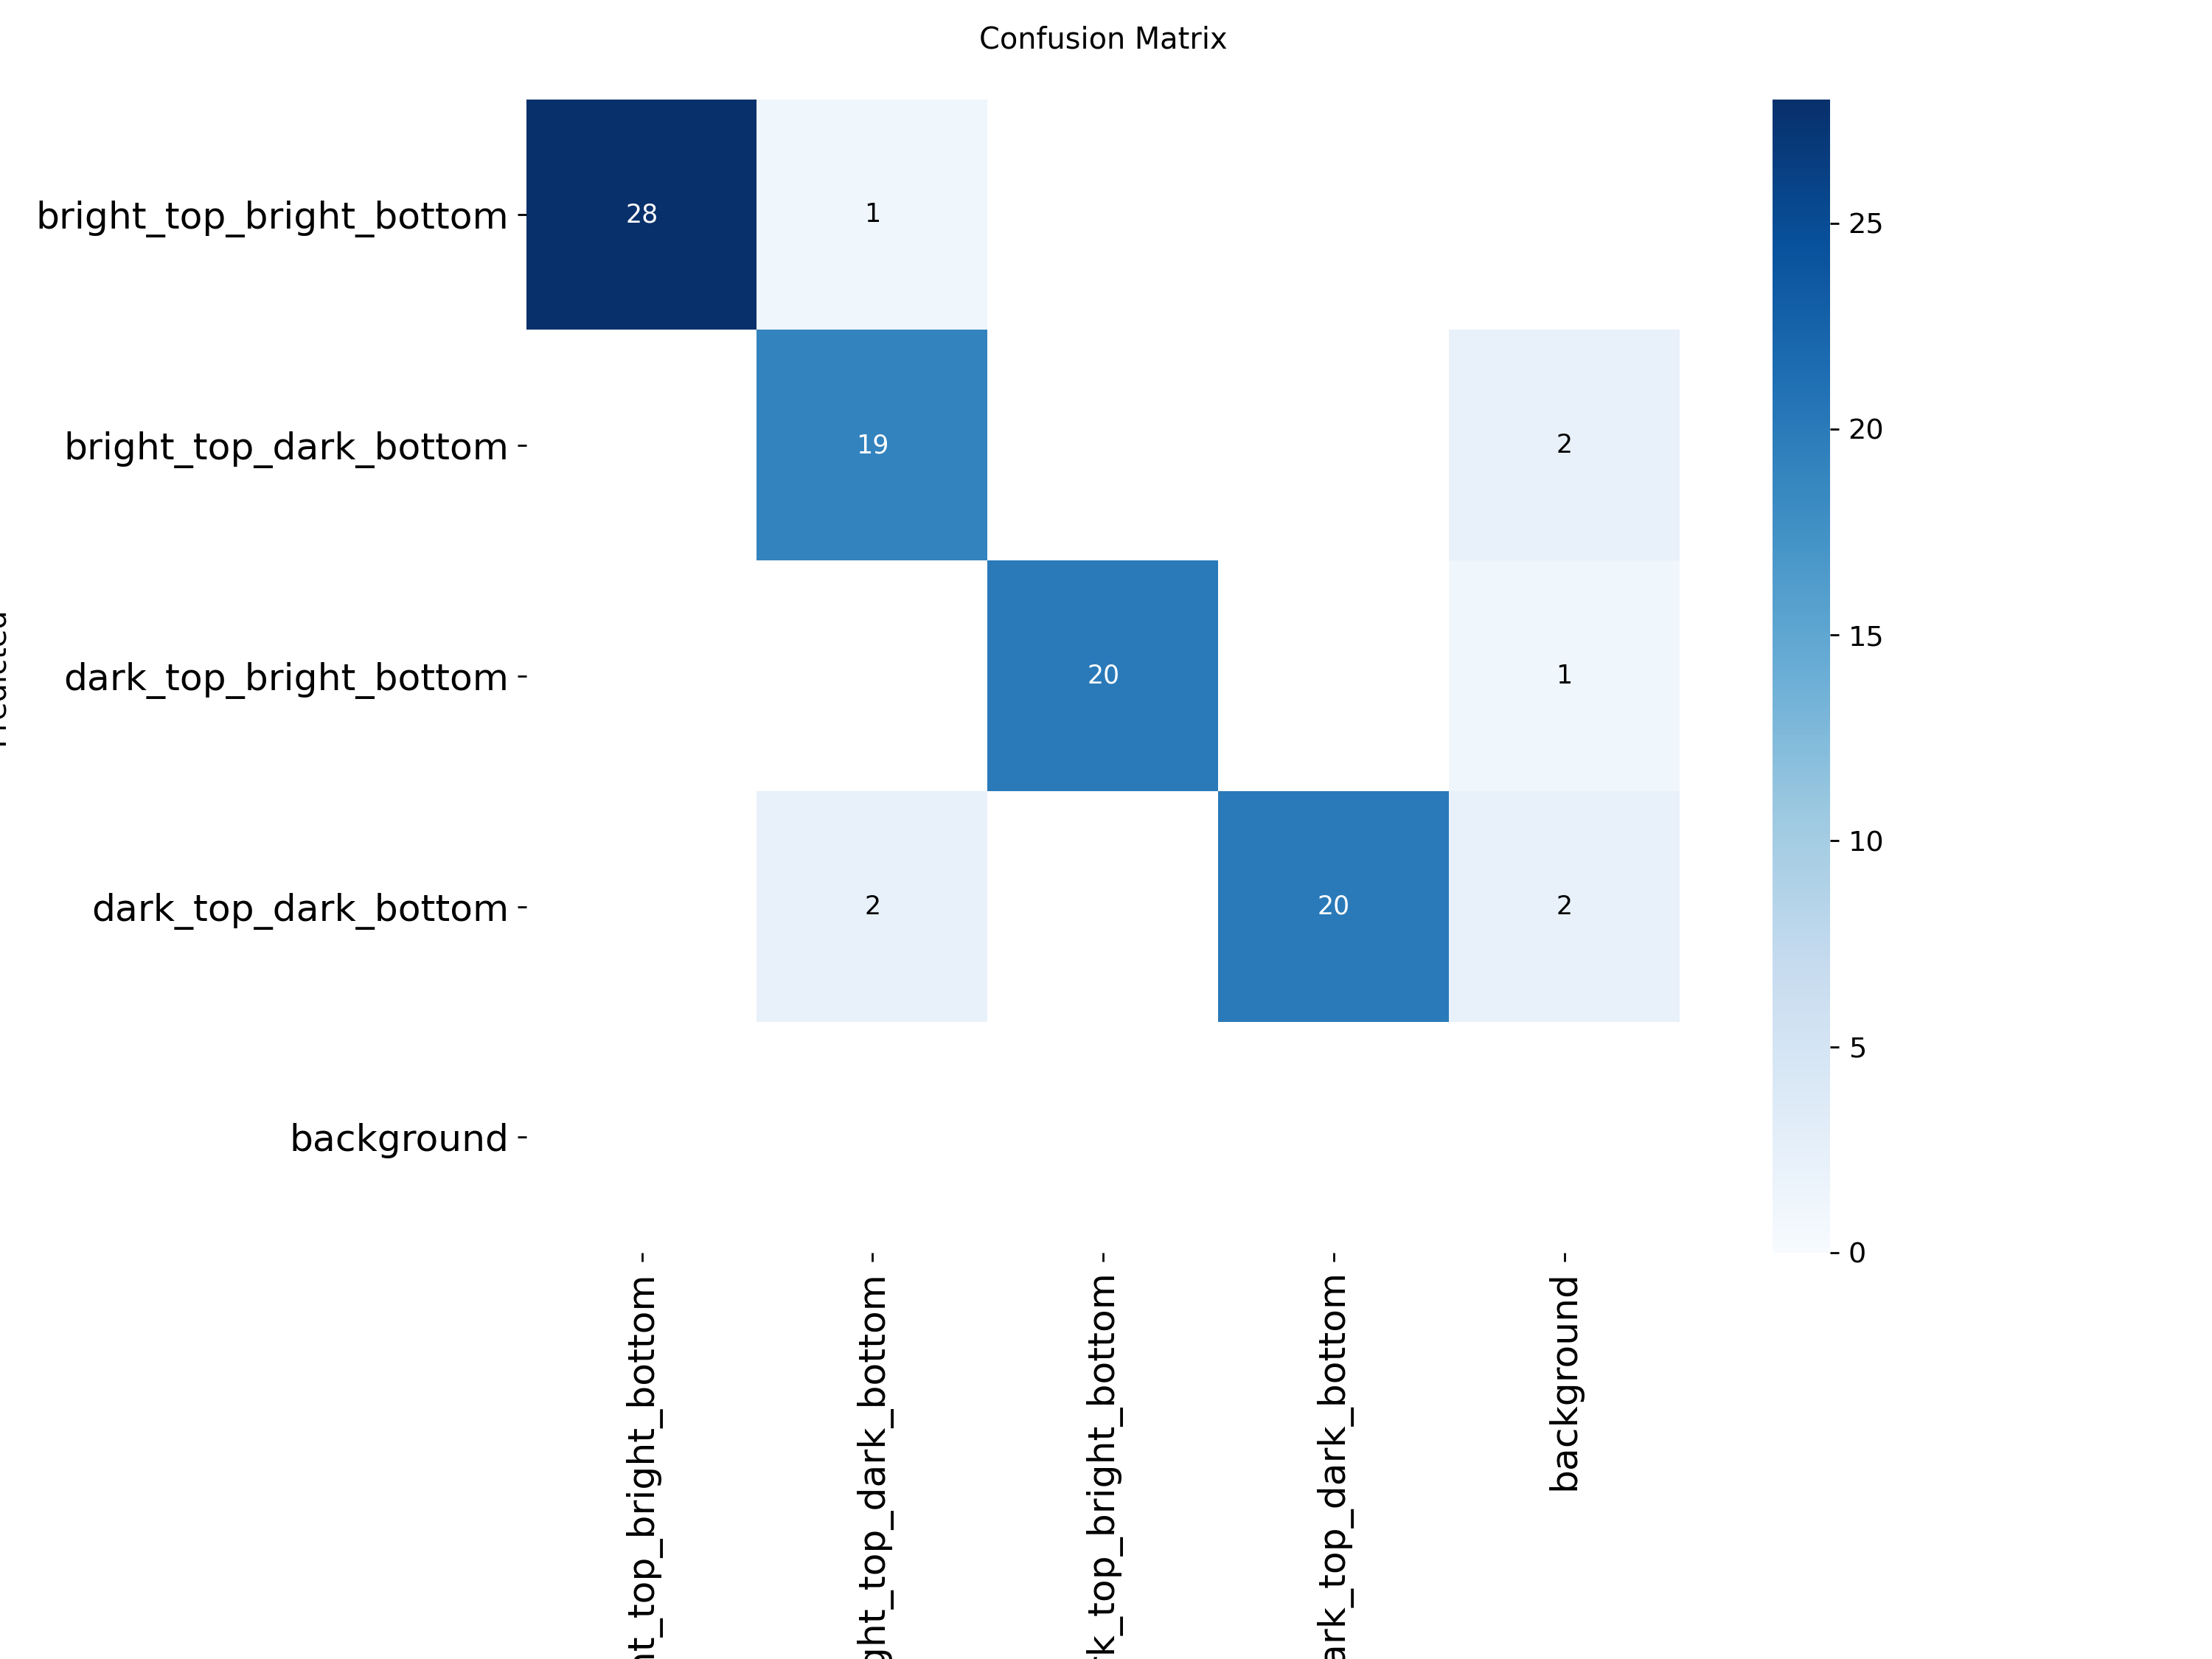

In [ ]:
import glob
from IPython.display import Image, display

# 두 번째 실험 폴더를 자동으로 찾습니다.
aug_folders = sorted(glob.glob('/content/runs/detect/FindEye_Experiments/aug_brightness_exp*'))

if aug_folders:
    latest_folder = aug_folders[-1]
    print(f"=== 2. 밝기 증강 실험: 학습 곡선 ({latest_folder}) ===")
    display(Image(f'{latest_folder}/results.png'))

    print("\n=== 2. 밝기 증강 실험: 오분류표 ===")
    display(Image(f'{latest_folder}/confusion_matrix.png'))
else:
    print("두 번째 실험 폴더를 아직 찾을 수 없습니다. (학습 진행 중일 수 있습니다)")

**전체 결론**


             📊 [Final Epoch Metrics Summary]             


,Precision,Recall,mAP50,mAP50-95
Experiment,,,,
Baseline (Default),0.94736,0.97443,0.98879,0.80956
LR Exp (0.005),0.87418,0.89746,0.94486,0.65330
Aug Exp (0.2),0.95386,0.96239,0.98995,0.79788


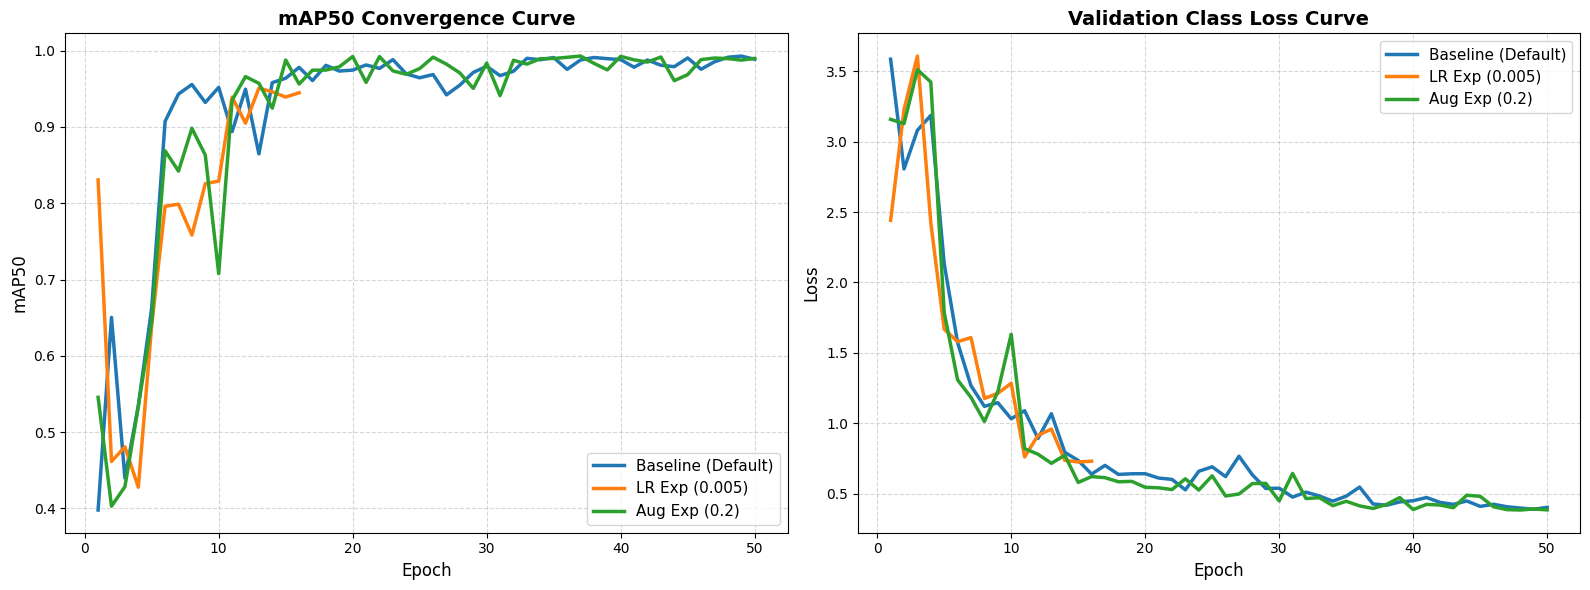

In [ ]:
import pandas as pd
import glob
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

# 1. 비교할 실험 경로 지정 (100 Epoch 실험 추가)
paths = {
    "0. Baseline (50e)": "/content/drive/MyDrive/FindEye/weights/results.csv",
    "1. LR 0.005 (50e)": "/content/runs/detect/FindEye_Experiments/lr_0005_exp*/results.csv",
    "2. Aug 0.2 (50e)": "/content/runs/detect/FindEye_Experiments/aug_brightness_exp*/results.csv",
    "👑 최종 100 Epoch (LR 0.005 + Aug 0.2)": "/content/runs/detect/FindEye_Experiments/final_100epoch_exp*/results.csv"
}

dfs = {}
summary_list = []

# 2. 데이터 로드
for exp_name, search_path in paths.items():
    files = sorted(glob.glob(search_path))
    if not files:
        print(f"⚠️ [{exp_name}] 결과 파일을 찾을 수 없습니다.")
        continue

    df = pd.read_csv(files[-1])
    df.columns = df.columns.str.strip()
    dfs[exp_name] = df

    # 마지막 에폭 데이터 추출
    final_epoch = df.iloc[-1]
    summary_list.append({
        "실험명": exp_name,
        "Total Epochs": int(final_epoch.name) + 1, # 총 학습 에폭 수 확인
        "정밀도 (Precision)": round(final_epoch["metrics/precision(B)"], 4),
        "재현율 (Recall)": round(final_epoch["metrics/recall(B)"], 4),
        "mAP50": round(final_epoch["metrics/mAP50(B)"], 4),
        "mAP50-95": round(final_epoch["metrics/mAP50-95(B)"], 4)
    })

# 3. 요약 표 출력
if summary_list:
    print("\n" + "="*80)
    print("                 📊 [모든 실험 최종 에폭 성능 지표 요약]                 ")
    print("="*80)
    display(pd.DataFrame(summary_list).set_index("실험명"))
    print("="*80 + "\n")

# 4. 세련된 인터랙티브 그래프 그리기
if dfs:
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("📈 mAP50 정확도 추이", "📉 Validation Loss 추이")
    )

    # 색상 지정 (4개 모델)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, (exp_name, df) in enumerate(dfs.items()):
        # X축을 강제로 리스트로 만들어 길이를 맞춤
        epochs = list(range(1, len(df) + 1))

        if "metrics/mAP50(B)" in df.columns:
            fig.add_trace(
                go.Scatter(x=epochs, y=df["metrics/mAP50(B)"],
                           mode='lines', name=exp_name,
                           line=dict(color=colors[i], width=3 if i!=3 else 4,
                                     dash='solid' if i!=3 else 'dot')), # 100 Epoch 선은 점선으로 강조
                row=1, col=1
            )
        if "val/cls_loss" in df.columns:
            fig.add_trace(
                go.Scatter(x=epochs, y=df["val/cls_loss"],
                           mode='lines', name=exp_name, showlegend=False,
                           line=dict(color=colors[i], width=3 if i!=3 else 4,
                                     dash='solid' if i!=3 else 'dot')),
                row=1, col=2
            )

    fig.update_layout(
        title_text="<b>FindEye 모델 100 Epoch 최종 검증 시각화</b>",
        title_font_size=20,
        hovermode="x unified",
        template="plotly_white",
        legend=dict(yanchor="bottom", y=0.01, xanchor="right", x=0.99, bgcolor="rgba(255, 255, 255, 0.8)")
    )

    fig.update_xaxes(title_text="Epoch", row=1, col=1)
    fig.update_xaxes(title_text="Epoch", row=1, col=2)
    fig.update_yaxes(title_text="mAP50 Score", row=1, col=1)
    fig.update_yaxes(title_text="Loss Value", row=1, col=2)

    fig.show()

In [ ]:
import pandas as pd
import glob
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

# ==========================================
# 📊 1. 평가 및 시각화를 수행하는 공통 함수
# ==========================================
def compare_experiments(experiment_title, paths_dict):
    dfs = {}
    summary_list = []

    for exp_name, search_path in paths_dict.items():
        files = sorted(glob.glob(search_path))
        if not files:
            print(f"⚠️ [{exp_name}] 결과 파일을 찾을 수 없습니다: {search_path}")
            continue

        df = pd.read_csv(files[-1])
        df.columns = df.columns.str.strip()
        dfs[exp_name] = df

        final_epoch = df.iloc[-1]
        summary_list.append({
            "실험 모델명": exp_name,
            "Total Epochs": int(final_epoch.name) + 1,
            "정밀도 (Precision)": round(final_epoch["metrics/precision(B)"], 4),
            "재현율 (Recall)": round(final_epoch["metrics/recall(B)"], 4),
            "mAP50": round(final_epoch["metrics/mAP50(B)"], 4),
            "mAP50-95": round(final_epoch["metrics/mAP50-95(B)"], 4)
        })

    if summary_list:
        print("\n" + "="*80)
        print(f"                 🏆 [{experiment_title} 최종 에폭 성능 요약]                 ")
        print("="*80)
        display(pd.DataFrame(summary_list).set_index("실험 모델명"))
        print("="*80 + "\n")

    if dfs:
        fig = make_subplots(
            rows=1, cols=2,
            subplot_titles=("📈 mAP50 정확도 추이", "📉 Validation Loss 추이")
        )

        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

        for i, (exp_name, df) in enumerate(dfs.items()):
            epochs = list(range(1, len(df) + 1))
            line_style = dict(color=colors[i % len(colors)], width=3)

            if "metrics/mAP50(B)" in df.columns:
                fig.add_trace(
                    go.Scatter(x=epochs, y=df["metrics/mAP50(B)"], mode='lines', name=exp_name, line=line_style),
                    row=1, col=1
                )
            if "val/cls_loss" in df.columns:
                fig.add_trace(
                    go.Scatter(x=epochs, y=df["val/cls_loss"], mode='lines', name=exp_name, showlegend=False, line=line_style),
                    row=1, col=2
                )

        fig.update_layout(
            title_text=f"<b>{experiment_title} 시각화</b>",
            title_font_size=20, hovermode="x unified", template="plotly_white",
            legend=dict(yanchor="bottom", y=0.01, xanchor="right", x=0.99, bgcolor="rgba(255, 255, 255, 0.8)")
        )

        fig.update_xaxes(title_text="Epoch", row=1, col=1)
        fig.update_xaxes(title_text="Epoch", row=1, col=2)
        fig.update_yaxes(title_text="mAP50 Score", row=1, col=1)
        fig.update_yaxes(title_text="Loss Value", row=1, col=2)

        fig.show()

# ==========================================
# 🚀 2. 그룹별 경로 지정 및 실행
# ==========================================

# 📌 첫 번째 실험: 학습률(LR) 비교 (100 Epoch 기준)
lr_experiments = {
    "Baseline 100e (LR 0.01)": "/content/runs/detect/FindEye_Final_Experiment/baseline_100e*/results.csv",
    "Optimized 100e (LR 0.005)": "/content/runs/detect/FindEye_Final_Experiment/optimized_100e*/results.csv"
}

# 📌 두 번째 실험: 밝기 증강(Aug) 비교 (50 Epoch 기준)
aug_experiments = {
    "Baseline 50e (기본)": "/content/drive/MyDrive/FindEye/weights/results.csv",
    "Aug Modified 50e (hsv_v 0.2)": "/content/runs/detect/FindEye_Experiments/aug_brightness_exp*/results.csv"
}

# 함수 실행!
compare_experiments("🔍 학습률(LR) 최적화 실험 (100 Epoch)", lr_experiments)
compare_experiments("🔍 밝기 증강(Augmentation) 최적화 실험 (50 Epoch)", aug_experiments)

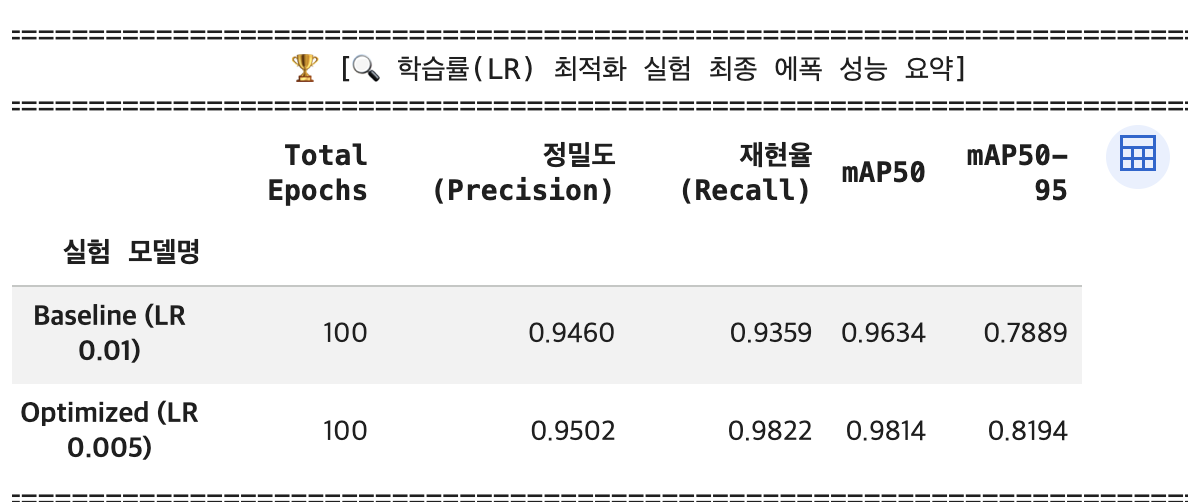

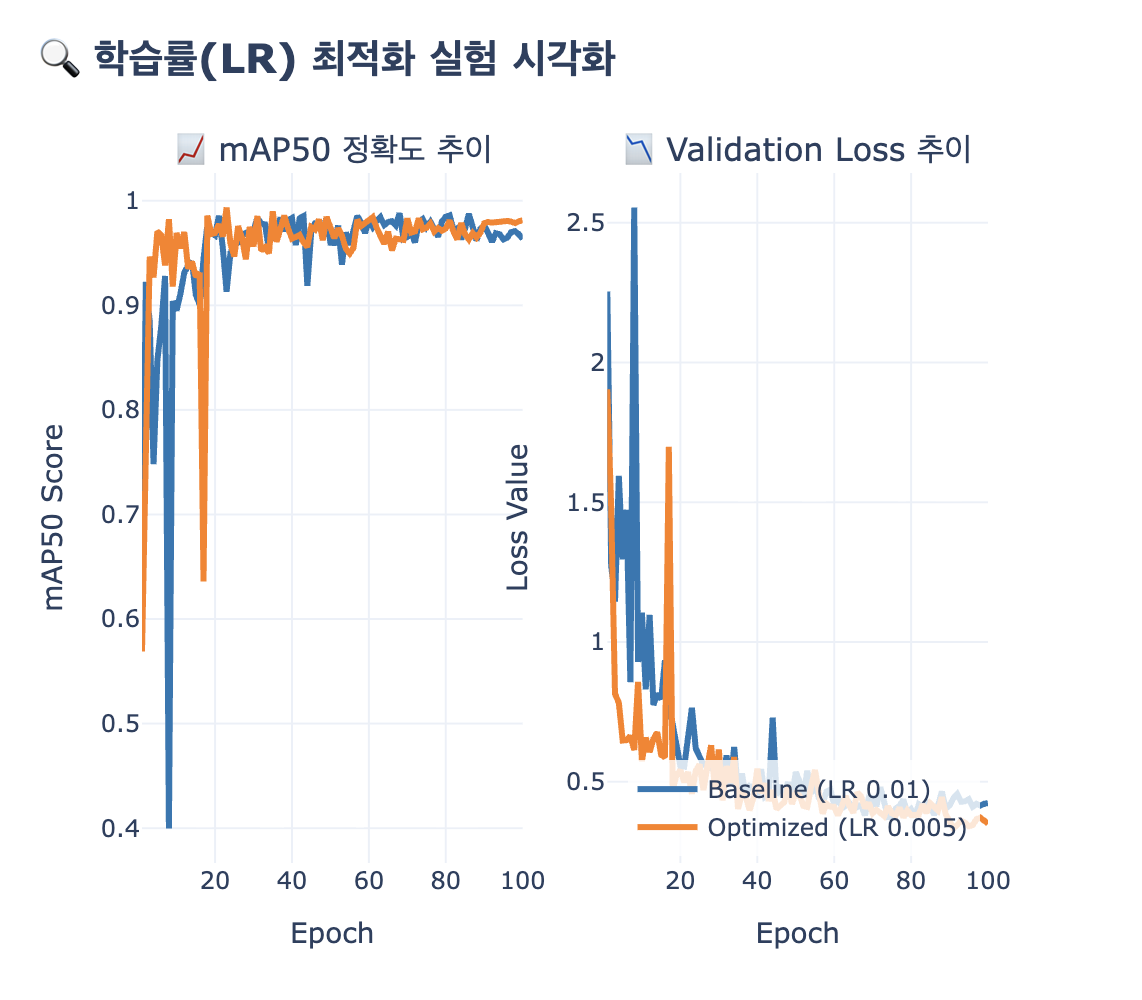